In [2]:
using Pkg
Pkg.activate("../scripts/calval")
using IceFloeTracker
using Images
using DataFrames
using CSVFiles

  Activating project at `~/Documents/research/manuscripts/calval_tgrs/scripts/calval`


# Filter Floes
The filter floes function is designed to remove false positives prior to the "merge floes" step. To calibrate the filter floes function, we identify objects belong to no relevant sets based on the manually identified floes. This should give us quite a few shapes to work with.

In [11]:
dataset = Watkins2026Dataset(;
    url="https://github.com/danielmwatkins/ice-floe-validation-dataset/",
    ref="v0.2",
    cache_dir="/tmp/Watkins2026",
    metadata_path="data/validation_dataset/validation_dataset.csv",
)

#### Run this to use the previously defined test/train split ####
prior_data = DataFrame(load("../data/train_test_split.csv"))
dataset.info[:, :training_sample] = parse.(Bool, prior_data[:, :training_sample])
dataset.info[:, :testing_sample] = parse.(Bool, prior_data[:, :testing_sample])
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

train_cases.info[:, :lookup_index] = 1:nrow(train_cases.info)
test_cases.info[:, :lookup_index] = 1:nrow(test_cases.info);

cluster_algo = IceDetectionBrightnessPeaksMODIS721(;
        band_7_max=0.16,
        possible_ice_threshold=0.6,
        join_method="union",
        minimum_prominence=0.01,
    )

cleanup_binary_params = (erosion_strel=strel_box((3, 3)), init_max_fill=100, conditional_max_fill=500
)
floe_splitting_params = (max_hole_fill=2000, max_distance=5, max_expand=3)

function clean_split_label(binary_mask, ice_mask, cloud_mask)
    return FSPipeline.dist_morph_split(
        FSPipeline.clean_binary_floes(binary_mask, ice_mask, cloud_mask; cleanup_binary_params...);
        floe_splitting_params...,
    )
end

# Workflows produce labeled arrays, not segmented images
function kmeans_workflow(preproc_gray, fc_masked, water_mask, ice_mask, cloud_mask; k=4, cluster_selection_algorithm=cluster_algo)
    masked_gray = apply_landmask(preproc_gray, water_mask)
    kmeans_result = kmeans_binarization(
        masked_gray, fc_masked; k=k, cluster_selection_algorithm=cluster_algo) .> 0
    return clean_split_label(kmeans_result, ice_mask, cloud_mask)
end

function adaptive_workflow(preproc_gray, land_mask, water_mask, ice_mask, cloud_mask; window_size=400, percentage=0)
    adaptive_result = binarize(preproc_gray, AdaptiveThreshold(; window_size=window_size, percentage=percentage)) .> 0
    apply_landmask!(adaptive_result, land_mask)
    apply_landmask!(adaptive_result, water_mask)
    return clean_split_label(adaptive_result .> 0, ice_mask, cloud_mask)    
end

adaptive_workflow (generic function with 2 methods)

In [5]:
case = train_cases

function fill_missing!(cases; template=Gray.(zeros(Bool, (400, 400))))
    for (idx, img) in enumerate(cases)
        if isnothing(img)
            cases[idx] = template
        end
    end
end

cloud_mask_function = Watkins2026CloudMask(
    band_7_threshold=0.16,
    band_2_threshold=0.34,
    opening_strel=strel_disk(3),
    dilation_strel=strel_disk(2)
)

ice_mask_function = IceDetectionBrightnessMidpoint(; minimum_reflectance=0.45)

@time begin
    tc_imgs = modis_truecolor.(case)
    fc_imgs = modis_falsecolor.(case)
    land_masks = modis_landmask.(case) .|> r -> r .> 0
    cloud_masks = cloud_mask_function.(fc_imgs)
    coastal_buffers = create_coastal_buffer_mask.(land_masks, [strel_box((25,25))])
    
    # joint_mask_buffers = ((x, y) -> x .|| y).(coastal_buffers, cloud_masks)
    
    # Mask images before k-means, preliminary ice mask application
    tc_masked = apply_landmask.(tc_imgs, land_masks)
    fc_masked = apply_landmask.(fc_imgs, land_masks)
    fc_buffered = apply_landmask.(fc_imgs, coastal_buffers)
    band_1 = fc_masked .|> r -> Gray.(blue.(r))
    ice_masks = ice_mask_function.(band_1) .|> r -> r .> 0
    # Masks have to be a full partition for this to work. So if the coastal buffer is used to make
    # the ice mask, it also must be used for the land mask here.
    water_masks = ((x, y, z) -> .!x .&& .!y .&& .!z).(land_masks, cloud_masks, ice_masks)
    
    # reference images
    binary_floes = validated_binary_floes.(case)
    fill_missing!(binary_floes)
end
nothing

192.011857 seconds (46.00 M allocations: 4.229 GiB, 1.38% gc time, 1 lock conflict, 3.90% compilation time: 4% of which was recompilation)


In [10]:
preproc_function = FSPipeline.Preprocess(
    diffusion_algorithm = PeronaMalikDiffusion(; λ=0.1, K=0.1, niters=5, g="exponential"),
    adapthisteq_params = (nbins=256, rblocks=2, cblocks=2, clip=5),
    unsharp_mask_params = (radius=50, amount=0.3, threshold=0.01),
)
tiles = get_tiles(tc_imgs[1], (400, 400)) # single tile
preproc_gray = preproc_function.(tc_imgs, land_masks, [tiles]);

In [12]:
adapt_labels = adaptive_workflow.(preproc_gray, land_masks, water_masks, ice_masks, cloud_masks; window_size=200, percentage=0);
kmeans_labels = kmeans_workflow.(preproc_gray, fc_buffered, water_masks, ice_masks, cloud_masks);

In [14]:
# TO DO:
# Get regionprops_tables, add circularity and boundary color as columns
# Use "relevant sets" to add an index to the property tables for "false_positive" 

40000.0

In [36]:
function extended_regionprops(img_indexmap, coastal_buffer_mask, cloud_mask, fc_img;
        min_floe_size=100, max_floe_size=90e3, expand_radius=15)
    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # Remove floes outside the specified bounds
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)

    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :convex_area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )
    
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2
    

    cloud_fractions = segment_mean(SegmentedImage(cloud_mask, img_indexmap))

    results_df[:, :cloud_fraction] = [cloud_fractions[L] for L in results_df[:, :label]]
    
    # mean reflectance
    b2_means = segment_mean(SegmentedImage(green.(fc_img), img_indexmap))
    bdry = IceFloeTracker.expand_labels(img_indexmap, expand_radius) .- img_indexmap
    b2_bdry_mean = segment_mean(SegmentedImage(green.(fc_img), bdry))
    results_df[:, :b2_reflectance_mean] = [b2_means[L] for L in results_df[:, :label]]
    results_df[:, :b2_reflectance_bdry_mean] = [
        b2_bdry_mean[L] for L in results_df[:, :label]
    ]

    results_df[:, :b2_bdry_contrast] =
        results_df[:, :b2_reflectance_mean] .- results_df[:, :b2_reflectance_bdry_mean]
    return results_df
end

extended_regionprops (generic function with 2 methods)

In [42]:
labeled_floes = label_components.(binary_floes)
df_true = extended_regionprops(labeled_floes[6], coastal_buffers[6], cloud_masks[6], fc_imgs[6])
df_pred = extended_regionprops(kmeans_labels[6], coastal_buffers[6], cloud_masks[6], fc_imgs[6])

Row,area,col_centroid,convex_area,label,major_axis_length,max_col,max_row,min_col,min_row,minor_axis_length,orientation,perimeter,row_centroid,circularity,cloud_fraction,b2_reflectance_mean,b2_reflectance_bdry_mean,b2_bdry_contrast
,Int64,Any,Float64,Int64,Any,Int64,Int64,Int64,Int64,Any,Any,Float64,Any,Float64,Float64,Float32,Float32,Float32
1,129,4.9845,129.0,1,17.0377,11,50,1,35,10.0475,-0.293822,43.5563,41.9302,0.85447,0.0,0.947774,0.674599,0.273175
2,560,16.5107,700.0,4,35.3168,35,213,1,186,26.1527,-1.56502,125.983,199.238,0.44338,1.0,0.97263,0.88232,0.0903105
3,210,7.68095,226.0,5,23.3011,17,252,1,230,12.5764,0.69674,64.663,242.052,0.631129,1.0,0.976079,0.817563,0.158515
4,165,7.82424,172.0,6,16.8565,15,299,1,284,13.3846,-0.616966,50.6274,292.036,0.808951,0.0,0.95249,0.784414,0.168076
5,117,9.23077,117.0,7,15.3652,16,280,2,270,9.75837,1.25455,40.3848,275.094,0.901489,1.0,0.987062,0.753089,0.233973
6,130,11.8231,131.0,8,13.8337,18,122,5,109,12.3585,0.679504,43.2132,114.846,0.874823,0.0,0.954722,0.768803,0.185919
7,457,26.2713,497.0,9,39.7546,43,23,8,1,15.827,-1.07565,103.598,10.547,0.535086,0.218818,0.953598,0.713128,0.240471
8,126,25.8651,128.0,13,15.7347,33,267,18,256,10.425,1.14697,43.2132,261.238,0.847906,1.0,0.983069,0.796119,0.18695
9,171,29.7544,173.0,14,18.7699,35,122,24,103,11.6987,-0.186285,50.0416,112.45,0.85811,0.345029,0.961266,0.765466,0.1958


In [46]:
relevant_set = FSPipeline.get_relevant_set(df_true, df_pred, labeled_floes[6], kmeans_labels[6]);

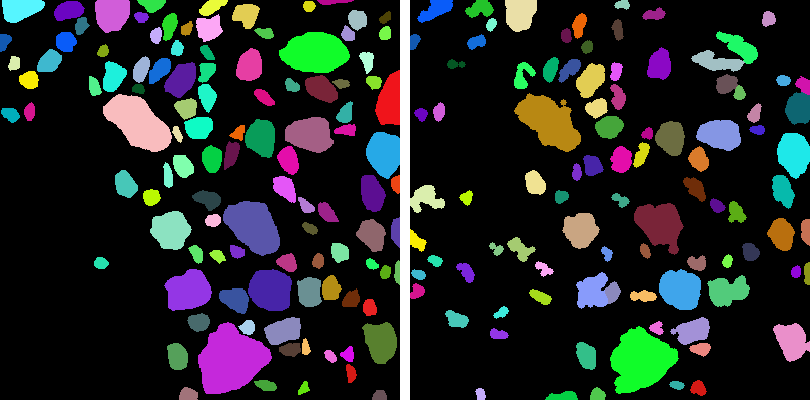

In [47]:
mosaicview(
RGBA.(view_seg_random(SegmentedImage(fc_imgs[6], labeled_floes[6]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[6], kmeans_labels[6]))),
npad=10, fillvalue=RGBA(0, 0, 0, 0),
nrow=1)

# Progress and to-do
1. The function above gives us the info we need to do the filtering (at least hopefully enough). It also is generally useful, so it could be used to simplify the FSPipeline.
2. Next, I need to add the column for "true positive" into the table. I want to know if the detected floes and the true floes are distributed the same according to the metrics.
3. Visualize the distributions for the collective set of false positives vs true positives.
4. Make calculation: object-wise precision and recall as a function of the thresholds?